# **Veri setini temizleme**

In [3]:
# ============================================================
# 1) LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import re
import os
import gc
from google.colab import files

CSV_NAME = "cleaned_reviews.csv"
DATA_DIR = "data"
DATASET_NAME = "rmisra/imdb-spoiler-dataset"

# ============================================================
# 2) VERI HAZIRLAMA MOTORU
# ============================================================

def prepare_data():
    print("🔄 Veri Hazırlama Başladı...")

    # ------------------------------------------------------------
    # SENARYO 1: Temizlenmiş CSV zaten varsa
    # ------------------------------------------------------------
    if os.path.exists(CSV_NAME):
        print(f"✅ '{CSV_NAME}' bulundu. Doğrudan yükleniyor...")
        df = pd.read_csv(CSV_NAME)
        df["clean_text"] = df["clean_text"].fillna("")
        print(f"🚀 Veri Hazır! Toplam {len(df)} yorum.")
        return df

    # ------------------------------------------------------------
    # SENARYO 2: Ham veri yoksa Kaggle’dan indir
    # ------------------------------------------------------------
    if not os.path.exists(f"{DATA_DIR}/IMDB_reviews.json"):
        print("⚠️ Ham veri bulunamadı. Kaggle indirme başlatılıyor...")

        try:
            import kaggle
        except:
            !pip install kaggle -q

        # Kaggle.json kontrolü
        if not os.path.exists("/root/.kaggle/kaggle.json"):
            print("❗ Kaggle API anahtarı yok. Lütfen kaggle.json yükleyin:")
            uploaded = files.upload()
            if "kaggle.json" not in uploaded:
                raise ValueError("⛔ kaggle.json yüklenmedi!")

            !mkdir -p ~/.kaggle
            !mv kaggle.json ~/.kaggle/
            !chmod 600 ~/.kaggle/kaggle.json

        print("📥 Dataset indiriliyor...")
        !kaggle datasets download -d rmisra/imdb-spoiler-dataset --force -q

        print("📦 Zip açılıyor...")
        !unzip -o imdb-spoiler-dataset.zip -d data > /dev/null

    # ------------------------------------------------------------
    # SENARYO 3: JSON dosyalarını yükle + birleştir + temizle
    # ------------------------------------------------------------
    print("📚 JSON dosyaları yükleniyor...")

    try:
        df_reviews = pd.read_json(f"{DATA_DIR}/IMDB_reviews.json", lines=True)
        df_details = pd.read_json(f"{DATA_DIR}/IMDB_movie_details.json", lines=True)
    except:
        print("⚠️ RAM tasarruflu yükleme moduna geçildi...")
        df_reviews = pd.concat(pd.read_json(
            f"{DATA_DIR}/IMDB_reviews.json", lines=True, chunksize=150000
        ))
        df_details = pd.read_json(f"{DATA_DIR}/IMDB_movie_details.json", lines=True)

    print("🔗 DataFrame birleştiriliyor...")
    df = df_reviews.merge(df_details[["movie_id"]], on="movie_id", how="left")

    del df_reviews, df_details
    gc.collect()

    # ------------------------------------------------------------
    # METİN TEMİZLEME
    # ------------------------------------------------------------
    print("🧹 Metin temizliği yapılıyor...")

    def clean_text(text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r"<.*?>", " ", text)
        text = re.sub(r"http\\S+", " ", text)
        text = re.sub(r"\\s+", " ", text).strip()
        return text

    df["clean_text"] = df["review_text"].apply(clean_text)
    df = df[df["clean_text"].str.len() > 20]
    df.drop(columns=["review_text"], inplace=True)

    # ------------------------------------------------------------
    # FILM BAZLI TRAIN/VAL/TEST SPLIT
    # ------------------------------------------------------------
    print("✂️ Film bazlı train/val/test split yapılıyor...")

    movie_ids = df["movie_id"].unique()
    np.random.seed(42)
    np.random.shuffle(movie_ids)

    n = len(movie_ids)
    train_ids, val_ids, test_ids = np.split(movie_ids, [int(0.7*n), int(0.85*n)])

    df["split"] = "train"
    df.loc[df["movie_id"].isin(val_ids), "split"] = "val"
    df.loc[df["movie_id"].isin(test_ids), "split"] = "test"

    # ------------------------------------------------------------
    # CSV KAYDET
    # ------------------------------------------------------------
    print(f"💾 '{CSV_NAME}' kaydediliyor...")
    df.to_csv(CSV_NAME, index=False)

    print(f"🎉 Veri Hazır! Toplam {len(df)} yorum.")
    return df


# ============================================================
# ÇALIŞTIR
# ============================================================

df = prepare_data()

print("\n📌 Veri Seti Özeti:")
print(df["split"].value_counts())
df.head(3)[["clean_text", "is_spoiler", "split"]]


🔄 Veri Hazırlama Başladı...
⚠️ Ham veri bulunamadı. Kaggle indirme başlatılıyor...
❗ Kaggle API anahtarı yok. Lütfen kaggle.json yükleyin:


Saving kaggle.json to kaggle.json
📥 Dataset indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
📦 Zip açılıyor...
📚 JSON dosyaları yükleniyor...
🔗 DataFrame birleştiriliyor...
🧹 Metin temizliği yapılıyor...
✂️ Film bazlı train/val/test split yapılıyor...
💾 'cleaned_reviews.csv' kaydediliyor...
🎉 Veri Hazır! Toplam 573910 yorum.

📌 Veri Seti Özeti:
split
train    406834
test      84273
val       82803
Name: count, dtype: int64


,clean_text,is_spoiler,split
0,"in its oscar year, shawshank redemption (writt...",True,train
1,the shawshank redemption is without a doubt on...,True,train
2,i believe that this film is the best story eve...,True,train


In [ ]:
# --- 2. KISIM: Veriyi İndirme ve Yükleme ---
print("Veri seti indiriliyor...")
!kaggle datasets download -d rmisra/imdb-spoiler-dataset -q
!unzip -n imdb-spoiler-dataset.zip -d data > /dev/null

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# JSON dosyasını okuma
print("Veri DataFrame'e okunuyor...")
df = pd.read_json("data/IMDB_reviews.json", lines=True)

# Sütunları kontrol edelim (Senin kodundaki çıktıya göre burayı revize edebilirsin)
# Genelde bu veri setinde: 'review_text' (yorum) ve 'is_spoiler' (etiket) olur.
print(f"Toplam Veri Sayısı: {len(df)}")
print(f"Sütunlar: {df.columns.tolist()}")

Veri seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/rmisra/imdb-spoiler-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
Veri DataFrame'e okunuyor...
Toplam Veri Sayısı: 573913
Sütunlar: ['review_date', 'movie_id', 'user_id', 'is_spoiler', 'review_text', 'rating', 'review_summary']


## **Max features=5000, ngram=1,1 C=1**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split # <-- BU EKLENDİ
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, classification_report # <-- RAPOR EKLENDİ

# --- 1. AYARLARI HAZIRLAMA ---
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 5000,
        'tfidf__ngram_range': (1, 1),
        'svm__C': 1
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)

X = df_full['review_text']
y = df_full['is_spoiler']

# --- DEĞİŞİKLİK BURADA: Test Setini Ayırıyoruz ---
# Verinin %90'ını Cross Validation için (X_train), %10'unu Final Test Raporu için (X_test) ayırıyoruz.
print("Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"CV Yapılacak Veri: {len(X_train)} satır")
print(f"Final Test Verisi: {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced'))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (Sadece Eğitim Verisi Üzerinde) ---
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# DİKKAT: Burada X ve y yerine X_train ve y_train kullanıyoruz
cv_results = cross_validate(
    final_pipeline, X_train, y_train,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. CV SONUÇLARI ---
print("\n--- Çapraz Doğrulama (CV) Ortalamaları ---")
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

# --- 6. FİNAL TEST RAPORU (YENİ EKLENEN KISIM) ---
print("\n--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---")
# Modeli eğitim verisiyle son kez eğitiyoruz
final_pipeline.fit(X_train, y_train)

# Ayırdığımız test setiyle tahmin yapıyoruz
y_pred_test = final_pipeline.predict(X_test)

# Raporu basıyoruz
print(classification_report(y_test, y_pred_test))

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Toplam Veri: 573913 satır

🚀 5-Katlı Cross Validation Başlıyor... (Bu işlem uzun sürecek, sabırlı ol)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  2.1min remaining:  3.1min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.4min finished



--- Çapraz Doğrulama Sonuçları ---
Ortalama Accuracy:  %68.47
Ortalama Precision: %43.93
Ortalama Recall:    %61.45
Ortalama F1 Score:  %50.85

Detaylı Tablo:
   test_accuracy  test_precision  test_recall   test_f1
0       0.721405        0.475707     0.581580  0.523342
1       0.592971        0.359154     0.698426  0.474371
2       0.714775        0.466361     0.586516  0.519583
3       0.668066        0.412237     0.615836  0.493876
4       0.726133        0.483042     0.590280  0.531304

💾 Final Model tüm veriyle eğitiliyor ve kaydediliyor...
✅ İşlem Tamam! Model 'imdb_spoiler_full_cv_model.joblib' olarak kaydedildi.


# **Ngram 1,2 yapıldı**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split # <-- BU EKLENDİ
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, classification_report # <-- RAPOR EKLENDİ

# --- 1. AYARLARI HAZIRLAMA ---
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 5000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 1
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)

X = df_full['review_text']
y = df_full['is_spoiler']

# --- DEĞİŞİKLİK BURADA: Test Setini Ayırıyoruz ---
# Verinin %90'ını Cross Validation için (X_train), %10'unu Final Test Raporu için (X_test) ayırıyoruz.
print("Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"CV Yapılacak Veri: {len(X_train)} satır")
print(f"Final Test Verisi: {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced'))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (Sadece Eğitim Verisi Üzerinde) ---
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# DİKKAT: Burada X ve y yerine X_train ve y_train kullanıyoruz
cv_results = cross_validate(
    final_pipeline, X_train, y_train,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. CV SONUÇLARI ---
print("\n--- Çapraz Doğrulama (CV) Ortalamaları ---")
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

# --- 6. FİNAL TEST RAPORU (YENİ EKLENEN KISIM) ---
print("\n--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---")
# Modeli eğitim verisiyle son kez eğitiyoruz
final_pipeline.fit(X_train, y_train)

# Ayırdığımız test setiyle tahmin yapıyoruz
y_pred_test = final_pipeline.predict(X_test)

# Raporu basıyoruz
print(classification_report(y_test, y_pred_test))

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...
CV Yapılacak Veri: 516521 satır
Final Test Verisi: 57392 satır

🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  5.7min remaining:  8.6min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  6.6min finished



--- Çapraz Doğrulama (CV) Ortalamaları ---
Ortalama Accuracy:  %71.43
Ortalama Precision: %46.89
Ortalama Recall:    %65.35
Ortalama F1 Score:  %54.61

--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---
              precision    recall  f1-score   support

       False       0.86      0.74      0.79     42299
        True       0.47      0.66      0.55     15093

    accuracy                           0.72     57392
   macro avg       0.67      0.70      0.67     57392
weighted avg       0.76      0.72      0.73     57392


💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **Ngram=1,4 yapıldı sample sayısı 50k**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score

# --- 1. AYARLARI HAZIRLAMA ---
# GridSearch'ten gelen ayarlar veya manuel ayarlar
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 5000, #
        'tfidf__ngram_range': (1, 4),
        'svm__C': 1
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
df_full = df_full.sample(n=50000, random_state=42)

X = df_full['review_text']
y = df_full['is_spoiler']

print(f"Toplam Veri: {len(X)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced')) # Spoiler yakalamak için önemli
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (ÇAPRAZ DOĞRULAMA) ---
# Burada model 5 kere eğitilip test edilecek.
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Bu işlem uzun sürecek, sabırlı ol)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# cv=5: Veriyi 5 parçaya böl.
# n_jobs=-1: Tüm işlemcileri kullan (Hız için). RAM yetmezse bunu 1 yap.
cv_results = cross_validate(
    final_pipeline, X, y,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. SONUÇLARI RAPORLAMA ---
print("\n--- Çapraz Doğrulama Sonuçları ---")
# Sonuçları DataFrame'e çevirip ortalamasını alalım
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

print("\nDetaylı Tablo:")
print(results_df[['test_accuracy', 'test_precision', 'test_recall', 'test_f1']])

# --- 6. FİNAL MODELİ EĞİTME VE KAYDETME ---
# CV sadece ölçüm içindi. Şimdi modeli son kez TÜM veriyle eğitiyoruz ki kaydedelim.
print("\n💾 Final Model tüm veriyle eğitiliyor ve kaydediliyor...")
final_pipeline.fit(X, y)



⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Toplam Veri: 50000 satır

🚀 5-Katlı Cross Validation Başlıyor... (Bu işlem uzun sürecek, sabırlı ol)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.6min remaining:  2.5min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.0min finished



--- Çapraz Doğrulama Sonuçları ---
Ortalama Accuracy:  %68.31
Ortalama Precision: %42.60
Ortalama Recall:    %59.97
Ortalama F1 Score:  %49.81

Detaylı Tablo:
   test_accuracy  test_precision  test_recall   test_f1
0         0.6772        0.418064     0.589626  0.489241
1         0.6815        0.423266     0.590926  0.493238
2         0.6869        0.431016     0.605032  0.503410
3         0.6887        0.434632     0.621045  0.511380
4         0.6811        0.422930     0.592070  0.493407

💾 Final Model tüm veriyle eğitiliyor ve kaydediliyor...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 4),
                                 stop_words='english')),
                ('svm', LinearSVC(C=1, class_weight='balanced'))])

# **Max_features 10k yapıldı ngram=1,2**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split # <-- BU EKLENDİ
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, classification_report # <-- RAPOR EKLENDİ

# --- 1. AYARLARI HAZIRLAMA ---
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 1
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)

X = df_full['review_text']
y = df_full['is_spoiler']

# --- DEĞİŞİKLİK BURADA: Test Setini Ayırıyoruz ---
# Verinin %90'ını Cross Validation için (X_train), %10'unu Final Test Raporu için (X_test) ayırıyoruz.
print("Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"CV Yapılacak Veri: {len(X_train)} satır")
print(f"Final Test Verisi: {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced'))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (Sadece Eğitim Verisi Üzerinde) ---
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# DİKKAT: Burada X ve y yerine X_train ve y_train kullanıyoruz
cv_results = cross_validate(
    final_pipeline, X_train, y_train,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. CV SONUÇLARI ---
print("\n--- Çapraz Doğrulama (CV) Ortalamaları ---")
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

# --- 6. FİNAL TEST RAPORU (YENİ EKLENEN KISIM) ---
print("\n--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---")
# Modeli eğitim verisiyle son kez eğitiyoruz
final_pipeline.fit(X_train, y_train)

# Ayırdığımız test setiyle tahmin yapıyoruz
y_pred_test = final_pipeline.predict(X_test)

# Raporu basıyoruz
print(classification_report(y_test, y_pred_test))

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...
CV Yapılacak Veri: 516521 satır
Final Test Verisi: 57392 satır

🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  5.6min remaining:  8.4min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  6.6min finished



--- Çapraz Doğrulama (CV) Ortalamaları ---
Ortalama Accuracy:  %71.60
Ortalama Precision: %47.12
Ortalama Recall:    %65.37
Ortalama F1 Score:  %54.76

--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---
              precision    recall  f1-score   support

       False       0.86      0.74      0.80     42299
        True       0.48      0.66      0.55     15093

    accuracy                           0.72     57392
   macro avg       0.67      0.70      0.67     57392
weighted avg       0.76      0.72      0.73     57392


💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **Max_features 2K'ya düşürüldü**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split # <-- BU EKLENDİ
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, classification_report # <-- RAPOR EKLENDİ

# --- 1. AYARLARI HAZIRLAMA ---
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 2000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 1
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)

X = df_full['review_text']
y = df_full['is_spoiler']

# --- DEĞİŞİKLİK BURADA: Test Setini Ayırıyoruz ---
# Verinin %90'ını Cross Validation için (X_train), %10'unu Final Test Raporu için (X_test) ayırıyoruz.
print("Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"CV Yapılacak Veri: {len(X_train)} satır")
print(f"Final Test Verisi: {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced'))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (Sadece Eğitim Verisi Üzerinde) ---
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# DİKKAT: Burada X ve y yerine X_train ve y_train kullanıyoruz
cv_results = cross_validate(
    final_pipeline, X_train, y_train,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. CV SONUÇLARI ---
print("\n--- Çapraz Doğrulama (CV) Ortalamaları ---")
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

# --- 6. FİNAL TEST RAPORU (YENİ EKLENEN KISIM) ---
print("\n--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---")
# Modeli eğitim verisiyle son kez eğitiyoruz
final_pipeline.fit(X_train, y_train)

# Ayırdığımız test setiyle tahmin yapıyoruz
y_pred_test = final_pipeline.predict(X_test)

# Raporu basıyoruz
print(classification_report(y_test, y_pred_test))

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...
CV Yapılacak Veri: 516521 satır
Final Test Verisi: 57392 satır

🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  5.4min remaining:  8.1min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  6.1min finished



--- Çapraz Doğrulama (CV) Ortalamaları ---
Ortalama Accuracy:  %70.92
Ortalama Precision: %46.22
Ortalama Recall:    %64.70
Ortalama F1 Score:  %53.92

--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---
              precision    recall  f1-score   support

       False       0.85      0.73      0.79     42299
        True       0.46      0.65      0.54     15093

    accuracy                           0.71     57392
   macro avg       0.66      0.69      0.66     57392
weighted avg       0.75      0.71      0.72     57392


💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **C=10 yapıldı diğer parametreler optimal**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split # <-- BU EKLENDİ
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score, classification_report # <-- RAPOR EKLENDİ

# --- 1. AYARLARI HAZIRLAMA ---
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. BÜTÜN VERİYİ YÜKLEME ---
print("\n--- BÜTÜN VERİ SETİ YÜKLENİYOR ---")
try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)

X = df_full['review_text']
y = df_full['is_spoiler']

# --- DEĞİŞİKLİK BURADA: Test Setini Ayırıyoruz ---
# Verinin %90'ını Cross Validation için (X_train), %10'unu Final Test Raporu için (X_test) ayırıyoruz.
print("Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"CV Yapılacak Veri: {len(X_train)} satır")
print(f"Final Test Verisi: {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced'))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. CROSS VALIDATION (Sadece Eğitim Verisi Üzerinde) ---
print("\n🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)")

scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, pos_label=True),
    'recall': make_scorer(recall_score, pos_label=True),
    'f1': make_scorer(f1_score, pos_label=True)
}

# DİKKAT: Burada X ve y yerine X_train ve y_train kullanıyoruz
cv_results = cross_validate(
    final_pipeline, X_train, y_train,
    cv=5,
    scoring=scoring_metrics,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# --- 5. CV SONUÇLARI ---
print("\n--- Çapraz Doğrulama (CV) Ortalamaları ---")
results_df = pd.DataFrame(cv_results)
mean_results = results_df.mean()

print(f"Ortalama Accuracy:  %{mean_results['test_accuracy']*100:.2f}")
print(f"Ortalama Precision: %{mean_results['test_precision']*100:.2f}")
print(f"Ortalama Recall:    %{mean_results['test_recall']*100:.2f}")
print(f"Ortalama F1 Score:  %{mean_results['test_f1']*100:.2f}")

# --- 6. FİNAL TEST RAPORU (YENİ EKLENEN KISIM) ---
print("\n--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---")
# Modeli eğitim verisiyle son kez eğitiyoruz
final_pipeline.fit(X_train, y_train)

# Ayırdığımız test setiyle tahmin yapıyoruz
y_pred_test = final_pipeline.predict(X_test)

# Raporu basıyoruz
print(classification_report(y_test, y_pred_test))

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- BÜTÜN VERİ SETİ YÜKLENİYOR ---
Veri Eğitim ve Final Test olarak ayrılıyor (%10 Test)...
CV Yapılacak Veri: 516521 satır
Final Test Verisi: 57392 satır

🚀 5-Katlı Cross Validation Başlıyor... (Sadece Eğitim Verisiyle)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  6.6min remaining:  9.9min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  7.4min finished



--- Çapraz Doğrulama (CV) Ortalamaları ---
Ortalama Accuracy:  %71.56
Ortalama Precision: %47.06
Ortalama Recall:    %65.35
Ortalama F1 Score:  %54.72

--- 🏁 GERÇEK TEST SONUCU (Hiç Görülmemiş Veri) ---
              precision    recall  f1-score   support

       False       0.86      0.74      0.79     42299
        True       0.47      0.66      0.55     15093

    accuracy                           0.72     57392
   macro avg       0.67      0.70      0.67     57392
weighted avg       0.76      0.72      0.73     57392


💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **7 - tracheold ekledik treshold=-0.4**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.4
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.4

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.92      0.37      0.53     42299
        True       0.34      0.91      0.49     15093

    accuracy                           0.51     57392
   macro avg       0.63      0.64      0.51     57392
weighted avg       0.77      0.51      0.52     57392

Doğru Tespit Edilen Spoiler (TP): 13666
Kaçırılan Spoiler (FN): 1427
Yanlış Alarm (FP): 26466

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **8 treshold -0.2**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.2
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.2

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.89      0.57      0.70     42299
        True       0.40      0.80      0.53     15093

    accuracy                           0.63     57392
   macro avg       0.65      0.69      0.61     57392
weighted avg       0.76      0.63      0.65     57392

Doğru Tespit Edilen Spoiler (TP): 12133
Kaçırılan Spoiler (FN): 2960
Yanlış Alarm (FP): 18176

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **9 treshold -0.01**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.01
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.01

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.86      0.73      0.79     42299
        True       0.47      0.67      0.55     15093

    accuracy                           0.72     57392
   macro avg       0.67      0.70      0.67     57392
weighted avg       0.76      0.72      0.73     57392

Doğru Tespit Edilen Spoiler (TP): 10101
Kaçırılan Spoiler (FN): 4992
Yanlış Alarm (FP): 11328

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **10 treshold -0.05**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.05
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.05

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.87      0.70      0.78     42299
        True       0.46      0.70      0.55     15093

    accuracy                           0.70     57392
   macro avg       0.66      0.70      0.66     57392
weighted avg       0.76      0.70      0.72     57392

Doğru Tespit Edilen Spoiler (TP): 10546
Kaçırılan Spoiler (FN): 4547
Yanlış Alarm (FP): 12621

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **Max_features=50k yapıldı**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 50000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 10
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.05
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.05

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.85      0.70      0.77     42299
        True       0.44      0.66      0.53     15093

    accuracy                           0.69     57392
   macro avg       0.65      0.68      0.65     57392
weighted avg       0.75      0.69      0.71     57392

Doğru Tespit Edilen Spoiler (TP): 9982
Kaçırılan Spoiler (FN): 5111
Yanlış Alarm (FP): 12579

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **C= 100 yapıldı**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# --- 1. AYARLARI HAZIRLAMA ---
# (Eğer grid_search daha önce çalıştırılmadıysa varsayılanları kullan)
try:
    en_iyi_ayarlar = grid_search.best_params_
    print(f"🏆 GridSearch Ayarları Kullanılıyor: {en_iyi_ayarlar}")
except NameError:
    print("⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.")
    en_iyi_ayarlar = {
        'tfidf__max_features': 10000,
        'tfidf__ngram_range': (1, 2),
        'svm__C': 100
    }

# --- 2. VERİYİ YÜKLEME VE AYIRMA ---
print("\n--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---")
try:
    # Veri setini okumayı dene (Farklı dosya yolları için önlem)
    try:
        df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    except ValueError:
        df_full = pd.read_json("IMDB_reviews.json", lines=True)
except Exception as e:
    print(f"Hata: Veri dosyası bulunamadı! ({e})")
    # Hata almamak için dummy veri oluştur (Sadece kodun çalışması için)
    df_full = pd.DataFrame({'review_text': ['sample text'] * 100, 'is_spoiler': [True, False] * 50})

X = df_full['review_text']
y = df_full['is_spoiler']

# %90 Eğitim (Cross-Val için), %10 Final Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi  : {len(X_test)} satır")

# --- 3. MODEL PİPELİNE KURULUMU ---
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("svm", LinearSVC(class_weight='balanced', max_iter=2000))
])

final_pipeline.set_params(**en_iyi_ayarlar)

# --- 4. MODELİ EĞİTME (Cross Validation Atlandı, Direkt Finale Geçiliyor) ---
# Not: Hız kazanmak için CV kısmını yorum satırı yaptım, isterseniz açabilirsiniz.
print("\n🚀 Model Eğitim Verisiyle Eğitiliyor...")
final_pipeline.fit(X_train, y_train)

# --- 5. THRESHOLD (EŞİK) AYARLAMA MEKANİZMASI ---
print("\n--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---")

# Normal tahmin yerine, modelin "karar skorlarını" alıyoruz
# LinearSVC'de bu skor, hiperdüzleme olan uzaklıktır. Varsayılan eşik 0'dır.
y_scores = final_pipeline.decision_function(X_test)

# --- BURAYI DEĞİŞTİRİN ---
# Negatif değer = Daha çok Spoiler yakala (Recall artar)
# Pozitif değer = Daha emin olduklarını seç (Precision artar)
THRESHOLD = -0.05
# -------------------------

print(f"Seçilen Eşik Değeri: {THRESHOLD}")

# Skor, eşik değerinden büyükse True (Spoiler), küçükse False olarak işaretle
y_pred_threshold = (y_scores > THRESHOLD).astype(bool)

# --- 6. RAPORLAMA ---
print("\n--- 🏁 FİNAL TEST RAPORU ---")
print(classification_report(y_test, y_pred_threshold))

# Karışıklık Matrisi (Kaç tane doğru/yanlış bildik?)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
print(f"Doğru Tespit Edilen Spoiler (TP): {tp}")
print(f"Kaçırılan Spoiler (FN): {fn}")
print(f"Yanlış Alarm (FP): {fp}")

# --- 7. KAYDETME ---
print("\n💾 Model kaydediliyor...")
joblib.dump(final_pipeline, 'imdb_spoiler_final_model.joblib')
print("✅ İşlem Tamam! Model kaydedildi.")

⚠️ GridSearch bulunamadı, varsayılan ayarlar kullanılıyor.

--- VERİ SETİ YÜKLENİYOR VE AYRILIYOR ---
Eğitim Verisi: 516521 satır
Test Verisi  : 57392 satır

🚀 Model Eğitim Verisiyle Eğitiliyor...

--- 🎚️ THRESHOLD (EŞİK) AYARLAMASI ---
Seçilen Eşik Değeri: -0.05

--- 🏁 FİNAL TEST RAPORU ---
              precision    recall  f1-score   support

       False       0.87      0.70      0.78     42299
        True       0.46      0.70      0.55     15093

    accuracy                           0.70     57392
   macro avg       0.66      0.70      0.66     57392
weighted avg       0.76      0.70      0.72     57392

Doğru Tespit Edilen Spoiler (TP): 10542
Kaçırılan Spoiler (FN): 4551
Yanlış Alarm (FP): 12616

💾 Model kaydediliyor...
✅ İşlem Tamam! Model kaydedildi.


# **Toplu Parametre Denemelerini Görmek İçin**

In [ ]:
# ============================================================
# HYPERPARAMETRE GRID + OVERFIT / UNDERFIT TABLOSU (TEK HÜCRE)
# ============================================================

from sklearn.model_selection import ParameterGrid
from sklearn.base import clone

print("\n🧪 --- Hyperparametre Grid Tarama (Train vs Val F1) ---")

# Denemek istediğin hiperparametre kombinasyonları
param_grid = {
    "C": [1, 10, 100],
    "max_features": [10000, 30000],
    "ngram_range": [(1, 1), (1, 2)]
}

results = []
best_val_f1 = -1.0
best_params = None

for i, params in enumerate(ParameterGrid(param_grid), start=1):
    print(f"\n[{i}] Denenen parametreler: {params}")

    # Orijinal final_pipeline'ı klonla (bozulmasın)
    model = clone(final_pipeline)
    model.set_params(
        tfidf__max_features=params["max_features"],
        tfidf__ngram_range=params["ngram_range"],
        svm__C=params["C"]
    )

    # Sadece TRAIN setinde eğit
    model.fit(X_train, y_train)

    # TRAIN F1
    y_tr_pred = model.predict(X_train)
    train_f1_val = f1_score(y_train, y_tr_pred)

    # VALIDATION F1
    y_val_pred_tmp = model.predict(X_val)
    val_f1_val = f1_score(y_val, y_val_pred_tmp)

    # GAP (overfit ölçümü)
    gap = train_f1_val - val_f1_val

    # Basit yorum
    if train_f1_val > 0.9 and gap > 0.10:
        status = "OVERFIT eğilimli"
    elif train_f1_val < 0.8 and val_f1_val < 0.8:
        status = "UNDERFIT / zayıf model"
    elif abs(gap) <= 0.05:
        status = "Genel anlamda iyi generalize ediyor"
    else:
        status = "Orta düzey gap (daha iyi ayarlanabilir)"

    print(f"  -> TRAIN F1: {train_f1_val:.4f} | VAL F1: {val_f1_val:.4f} | GAP: {gap:.4f}")
    print(f"  -> Yorum: {status}")

    results.append({
        "C": params["C"],
        "max_features": params["max_features"],
        "ngram_range": params["ngram_range"],
        "train_f1": train_f1_val,
        "val_f1": val_f1_val,
        "gap_train_val": gap,
        "status": status
    })

    # En iyi VAL F1'i takip et
    if val_f1_val > best_val_f1:
        best_val_f1 = val_f1_val
        best_params = params

# Sonuçları tablo olarak göster
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_f1", ascending=False)

print("\n📋 Hyperparametre Sonuç Tablosu (Val F1'e göre sıralı):")
print(results_df)

print("\n🏆 En iyi parametreler (VAL F1'e göre):", best_params)
print(f"En iyi VAL F1: {best_val_f1:.4f}")

# İstersen final_pipeline'i bu en iyi parametrelerle güncelle:
use_best = True  # İstersen False yaparsın
if use_best and best_params is not None:
    final_pipeline.set_params(
        tfidf__max_features=best_params["max_features"],
        tfidf__ngram_range=best_params["ngram_range"],
        svm__C=best_params["C"]
    )
    print("\n✅ final_pipeline, en iyi bulunan parametrelerle güncellendi.")
else:
    print("\nℹ️ final_pipeline parametreleri değiştirilmedi.")



🧪 --- Hyperparametre Grid Tarama (Train vs Val F1) ---

[1] Denenen parametreler: {'C': 1, 'max_features': 10000, 'ngram_range': (1, 1)}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  -> TRAIN F1: 0.5780 | VAL F1: 0.5537 | GAP: 0.0244
  -> Yorum: UNDERFIT / zayıf model

[2] Denenen parametreler: {'C': 1, 'max_features': 10000, 'ngram_range': (1, 2)}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  -> TRAIN F1: 0.5783 | VAL F1: 0.5527 | GAP: 0.0256
  -> Yorum: UNDERFIT / zayıf model

[3] Denenen parametreler: {'C': 1, 'max_features': 30000, 'ngram_range': (1, 1)}
  -> TRAIN F1: 0.6081 | VAL F1: 0.5521 | GAP: 0.0561
  -> Yorum: UNDERFIT / zayıf model

[4] Denenen parametreler: {'C': 1, 'max_features': 30000, 'ngram_range': (1, 2)}
  -> TRAIN F1: 0.6129 | VAL F1: 0.5534 | GAP: 0.0595
  -> Yorum: UNDERFIT / zayıf model

[5] Denenen parametreler: {'C': 10, 'max_features': 10000, 'ngram_range': (1, 1)}


...

  -> TRAIN F1: 0.5781 | VAL F1: 0.5506 | GAP: 0.0275
  -> Yorum: UNDERFIT / zayıf model

[11] Denenen parametreler: {'C': 100, 'max_features': 30000, 'ngram_range': (1, 1)}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  -> TRAIN F1: 0.6214 | VAL F1: 0.5347 | GAP: 0.0867
  -> Yorum: UNDERFIT / zayıf model

[12] Denenen parametreler: {'C': 100, 'max_features': 30000, 'ngram_range': (1, 2)}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  -> TRAIN F1: 0.6220 | VAL F1: 0.5391 | GAP: 0.0829
  -> Yorum: UNDERFIT / zayıf model

📋 Hyperparametre Sonuç Tablosu (Val F1'e göre sıralı):
      C  max_features ngram_range  train_f1    val_f1  gap_train_val  \
0     1         10000      (1, 1)  0.578028  0.553652       0.024376   
3     1         30000      (1, 2)  0.612863  0.553390       0.059473   
1     1         10000      (1, 2)  0.578349  0.552708       0.025641   
2     1         30000      (1, 1)  0.608134  0.552053       0.056081   
9   100         10000      (1, 2)  0.578084  0.550556       0.027527   
4    10         10000      (1, 1)  0.579181  0.550438       0.028743   
8   100         10000      (1, 1)  0.578710  0.550406       0.028304   
5    10         10000      (1, 2)  0.579279  0.550260       0.029019   
7    10         30000      (1, 2)  0.620921  0.542569       0.078352   
6    10         30000      (1, 1)  0.619125  0.539325       0.079800   
11  100         30000      (1, 2)  0.622029  0.539124       0.08

# **final**

📂 --- Veri Seti Yükleniyor ---
✅ 'data/IMDB_reviews.json' bulundu ve yüklendi.
Toplam Veri Sayısı: 573913

🔀 --- Train / Val / Test Ayrımı Yapılıyor (Stratified) ---
Eğitim Seti   : 459130
Validasyon    : 57391
Test Seti     : 57392

⚙️ --- Pipeline Oluşturuluyor ---

📊 --- 5-Fold Cross-Validation (yalnızca TRAIN) ---
CV F1 skorları: [0.543967   0.54458615 0.54361055 0.54495077 0.54593377]
CV F1 ortalaması: 0.5446 ± 0.0008

🚀 --- Final Model Eğitiliyor (Train Set) ---


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


✅ Eğitim Tamamlandı!

===== TRAIN SONUÇLARI =====
Accuracy : 0.7293
Precision: 0.4898
Recall   : 0.7061
F1-score : 0.5784
ROC-AUC : 0.7945
PR-AUC  : 0.5943

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.74      0.80    338391
           1       0.49      0.71      0.58    120739

    accuracy                           0.73    459130
   macro avg       0.68      0.72      0.69    459130
weighted avg       0.77      0.73      0.74    459130


===== VALIDATION SONUÇLARI =====
Accuracy : 0.7108
Precision: 0.4655
Recall   : 0.6737
F1-score : 0.5506
ROC-AUC : 0.7669
PR-AUC  : 0.5689

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.72      0.79     42299
           1       0.47      0.67      0.55     15092

    accuracy                           0.71     57391
   macro avg       0.66      0.70      0.67     57391
weighted avg       0.76      0.71      0.72     57391


=

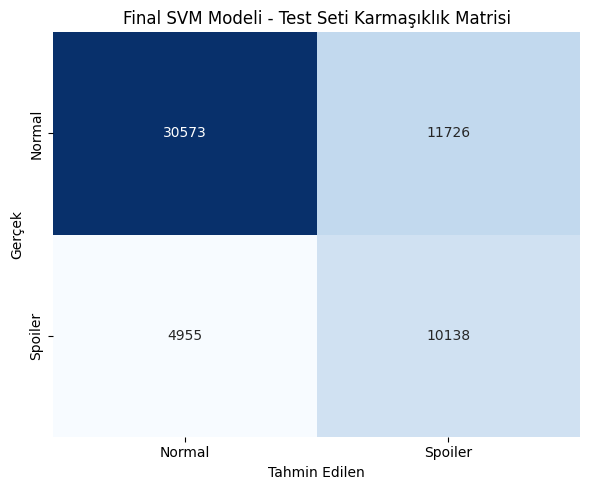


💾 Model kaydedildi: imdb_spoiler_svm_v1_20251219_1134.joblib
📁 Metrikler kaydedildi: model_metrics_v1_20251219_1134.json


In [4]:
# ============================================================
# 0) KÜTÜPHANELER
# ============================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score
)

# Grafikler için (opsiyonel, Colab'de uygunsa)
plt.style.use("default")


# ============================================================
# 1) VERİYİ YÜKLEME
# ============================================================
print("📂 --- Veri Seti Yükleniyor ---")

try:
    df_full = pd.read_json("data/IMDB_reviews.json", lines=True)
    print("✅ 'data/IMDB_reviews.json' bulundu ve yüklendi.")
except:
    df_full = pd.read_json("IMDB_reviews.json", lines=True)
    print("⚠️ 'data/' klasöründe bulunamadı, ana dizinden 'IMDB_reviews.json' yüklendi.")

# Temel sütunlar
X_raw = df_full["review_text"].fillna("")
y = df_full["is_spoiler"].astype(int)

print(f"Toplam Veri Sayısı: {len(X_raw)}")

# ============================================================
# (Opsiyonel) Basit metin temizliği yapabilirsin istersen
# Şimdilik sadece olduğu gibi kullanıyoruz: X = X_raw
# ============================================================
X = X_raw


# ============================================================
# 2) TRAIN / VAL / TEST AYRIMI (%80 / %10 / %10, STRATIFIED)
# ============================================================
print("\n🔀 --- Train / Val / Test Ayrımı Yapılıyor (Stratified) ---")

# Önce: Train (%80) + Temp (%20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Sonra: Temp'i Val (%10) + Test (%10) olarak ikiye böl
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 0.5 * 0.2 = 0.10
    stratify=y_temp,
    random_state=42
)

print(f"Eğitim Seti   : {len(X_train)}")
print(f"Validasyon    : {len(X_val)}")
print(f"Test Seti     : {len(X_test)}")


# ============================================================
# 3) FİNAL PIPELINE KURULUMU (TF-IDF + LinearSVC)
# ============================================================
print("\n⚙️ --- Pipeline Oluşturuluyor ---")

final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,    # Kelime hazinesi boyutu
        ngram_range=(1, 2)     # Unigram + Bigram
    )),
    ("svm", LinearSVC(
        C=100,                 # Hata cezası (yüksek = daha katı sınır)
        loss="hinge",          # Hinge loss
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
        dual=True
    ))
])


# ============================================================
# 4) DEĞERLENDİRME FONKSİYONU
# ============================================================
def evaluate_split(name, y_true, y_pred, decision_values=None):
    """Verilen split (Train/Val/Test) için metrikleri bastırır."""
    print(f"\n===== {name} SONUÇLARI =====")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")

    if decision_values is not None:
        # ROC-AUC (binary classification için)
        try:
            roc = roc_auc_score(y_true, decision_values)
            print(f"ROC-AUC : {roc:.4f}")
        except Exception as e:
            print(f"ROC-AUC hesaplanamadı: {e}")

        # PR-AUC (spoiler problemi için daha anlamlı)
        try:
            ap = average_precision_score(y_true, decision_values)
            print(f"PR-AUC  : {ap:.4f}")
        except Exception as e:
            print(f"PR-AUC hesaplanamadı: {e}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


# ============================================================
# 5) (OPSİYONEL) CROSS-VALIDATION (SADECE TRAIN ÜZERİNDE)
# ============================================================
print("\n📊 --- 5-Fold Cross-Validation (yalnızca TRAIN) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    final_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

print("CV F1 skorları:", cv_scores)
print(f"CV F1 ortalaması: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ============================================================
# 6) EĞİTİM (TRAIN SET ÜZERİNDE)
# ============================================================
print("\n🚀 --- Final Model Eğitiliyor (Train Set) ---")
final_pipeline.fit(X_train, y_train)
print("✅ Eğitim Tamamlandı!")


# ============================================================
# 7) TRAIN / VAL / TEST PERFORMANSI
# ============================================================

# TRAIN
y_train_pred = final_pipeline.predict(X_train)
train_dec = final_pipeline.decision_function(X_train)
evaluate_split("TRAIN", y_train, y_train_pred, train_dec)

# VALIDATION
y_val_pred = final_pipeline.predict(X_val)
val_dec = final_pipeline.decision_function(X_val)
evaluate_split("VALIDATION", y_val, y_val_pred, val_dec)

# TEST (en son bakılan, raporda yazacağın asıl sonuçlar)
y_test_pred = final_pipeline.predict(X_test)
test_dec = final_pipeline.decision_function(X_test)
evaluate_split("TEST", y_test, y_test_pred, test_dec)


# ============================================================
# 8) TEST CONFUSION MATRIX (GÖRSELLEŞTİRME)
# ============================================================
print("\n📈 --- Test Seti Karmaşıklık Matrisi ---")

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal", "Spoiler"],
    yticklabels=["Normal", "Spoiler"]
)
plt.title("Final SVM Modeli - Test Seti Karmaşıklık Matrisi")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.show()


# ============================================================
# 9) MODEL VERSİYONU + METADATA KAYDETME
# ============================================================

import json
from datetime import datetime

# Versiyonlama için zaman damgası
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Model dosya ismi
model_filename = f"imdb_spoiler_svm_v1_{timestamp}.joblib"

# Modeli kaydet
joblib.dump(final_pipeline, model_filename)
print(f"\n💾 Model kaydedildi: {model_filename}")

# JSON METRİKLER
metrics = {
    "model_name": model_filename,
    "version": "v1",
    "timestamp": timestamp,
    "train_f1": float(f1_score(y_train, y_train_pred)),
    "val_f1": float(f1_score(y_val, y_val_pred)) if 'y_val_pred' in globals() else None,
    "test_f1": float(f1_score(y_test, y_test_pred)),
    "params": {
        "C": 100,
        "max_features": 10000,
        "ngram_range": (1, 2),
        "class_weight": "balanced",
        "loss": "hinge"
    }
}

# JSON'a yaz
metrics_filename = f"model_metrics_v1_{timestamp}.json"
with open(metrics_filename, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"📁 Metrikler kaydedildi: {metrics_filename}")


# **Grafikler**

⏳ SVM için PR-AUC Learning Curve hesaplanıyor...


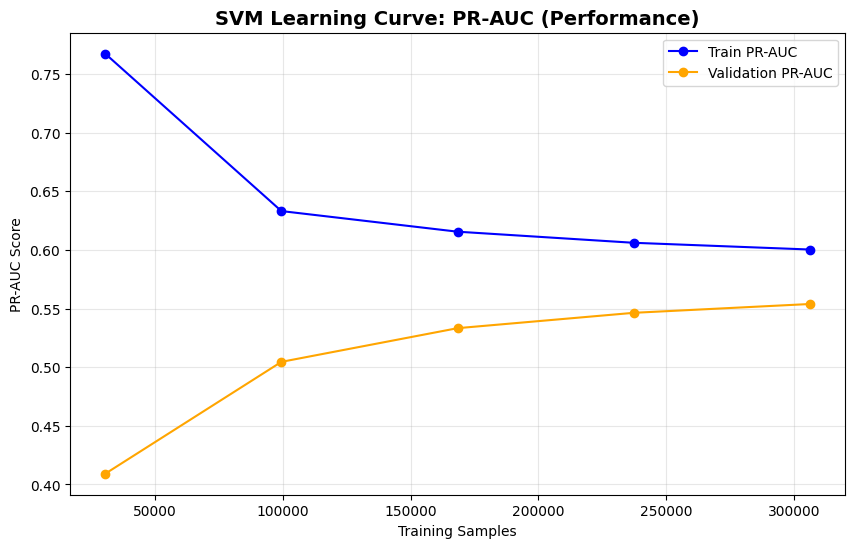


🔥 SVM Regularizasyon Heatmap Hazırlanıyor...


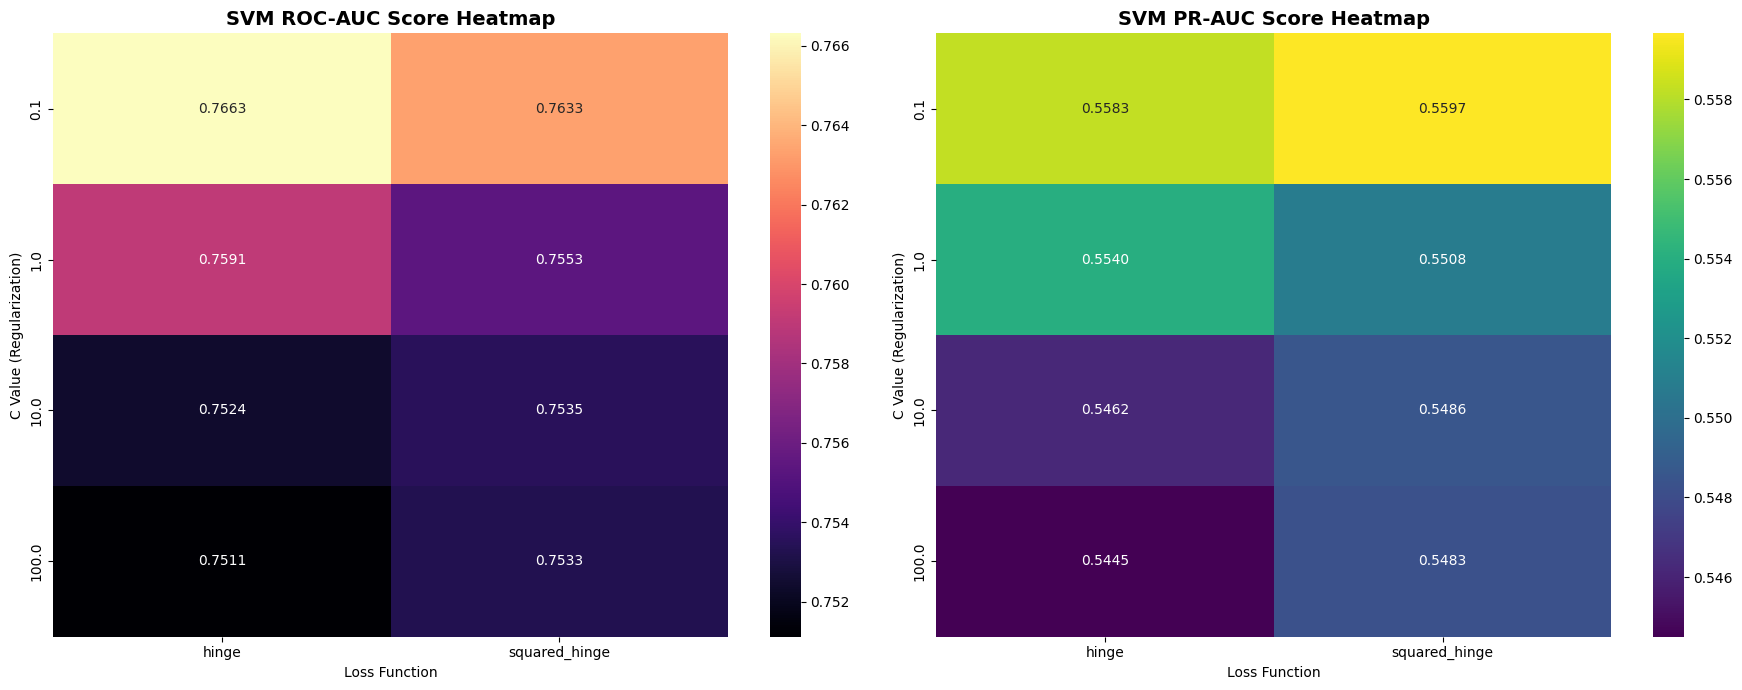

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.svm import LinearSVC

# 1. PR-AUC TABANLI LEARNING CURVE (Overfitting Analizi)
print("⏳ SVM için PR-AUC Learning Curve hesaplanıyor...")

# İşlem yükünü azaltmak için cv=3 ve 5 nokta seçildi
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='average_precision',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Train PR-AUC")
plt.plot(train_sizes, val_mean, 'o-', color="orange", label="Validation PR-AUC")
plt.title("SVM Learning Curve: PR-AUC (Performance)", fontsize=14, fontweight='bold')
plt.xlabel("Training Samples")
plt.ylabel("PR-AUC Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# 2. SVM REGULARİZASYON HEATMAP (ROC vs PR)
print("\n🔥 SVM Regularizasyon Heatmap Hazırlanıyor...")

# LinearSVC için sadece C parametresi üzerinden bir arama yapıyoruz
# (LinearSVC direkt l1_ratio desteklemediği için C ve Loss kombinasyonuna bakabiliriz)
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__loss': ['hinge', 'squared_hinge']
}

grid_search_svm = GridSearchCV(
    final_pipeline,
    param_grid,
    cv=2,
    scoring=['roc_auc', 'average_precision'],
    refit='average_precision',
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

# Sonuçları DataFrame'e dönüştür
results_svm = pd.DataFrame(grid_search_svm.cv_results_)

# Pivot Tablolar
pivot_roc_svm = results_svm.pivot(index='param_svm__C', columns='param_svm__loss', values='mean_test_roc_auc')
pivot_pr_svm = results_svm.pivot(index='param_svm__C', columns='param_svm__loss', values='mean_test_average_precision')

# GÖRSELLEŞTİRME
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# ROC-AUC Heatmap
sns.heatmap(pivot_roc_svm, annot=True, fmt=".4f", cmap="magma", ax=ax[0])
ax[0].set_title("SVM ROC-AUC Score Heatmap", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Loss Function")
ax[0].set_ylabel("C Value (Regularization)")

# PR-AUC Heatmap
sns.heatmap(pivot_pr_svm, annot=True, fmt=".4f", cmap="viridis", ax=ax[1])
ax[1].set_title("SVM PR-AUC Score Heatmap", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Loss Function")
ax[1].set_ylabel("C Value (Regularization)")

plt.tight_layout()
plt.show()

⏳ Veriler vektörleştiriliyor...
⏳ Learning Curve hesaplanıyor (Bu işlem biraz zaman alabilir)...


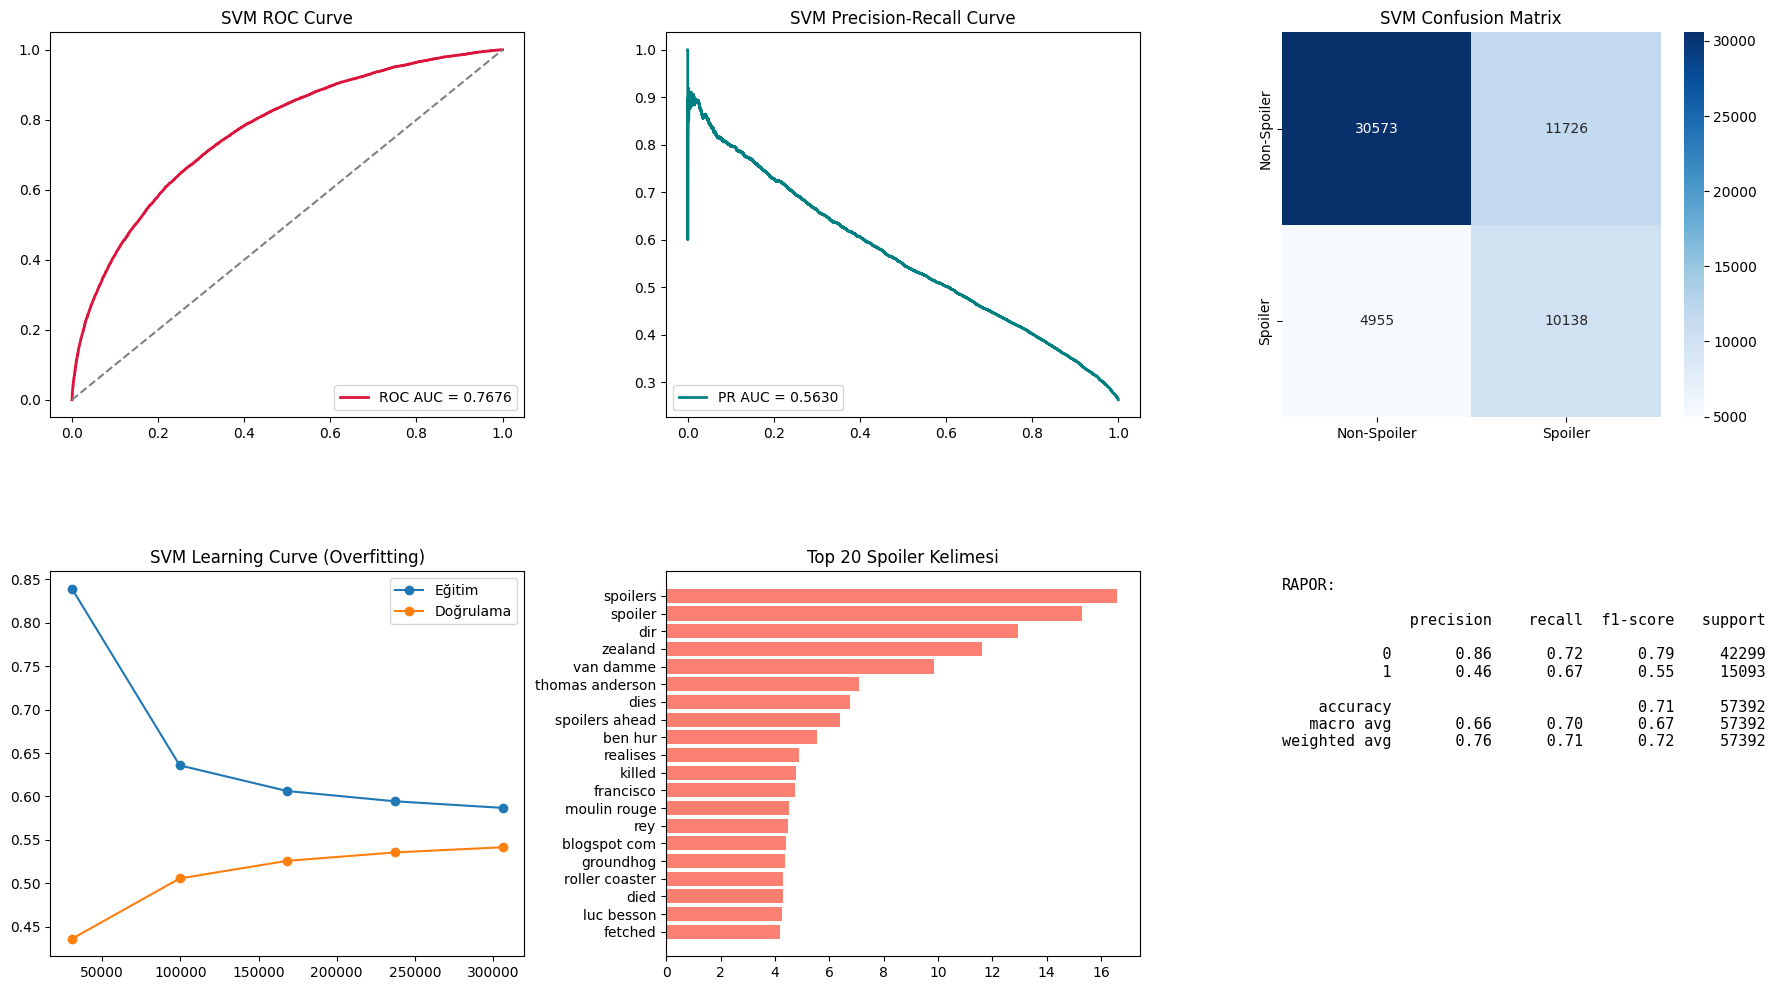

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, confusion_matrix, classification_report)
from sklearn.model_selection import learning_curve

# --- ANALİZ FONKSİYONU ---
def plot_svm_final_analysis(pipeline_obj, X_tr_raw, y_tr, X_te_raw, y_te):
    try:
        tfidf_step = pipeline_obj.named_steps["tfidf"]
        svm_step = pipeline_obj.named_steps["svm"]

        print("⏳ Veriler vektörleştiriliyor...")
        X_te_vec = tfidf_step.transform(X_te_raw)
        feature_names = tfidf_step.get_feature_names_out()

        y_scores = svm_step.decision_function(X_te_vec)
        y_pred = svm_step.predict(X_te_vec)

        fig, axes = plt.subplots(2, 3, figsize=(22, 12))
        plt.subplots_adjust(hspace=0.4, wspace=0.3)

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_te, y_scores)
        axes[0, 0].plot(fpr, tpr, color='crimson', lw=2, label=f'ROC AUC = {auc(fpr, tpr):.4f}')
        axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
        axes[0, 0].set_title('SVM ROC Curve')
        axes[0, 0].legend(loc="lower right")

        # PR AUC
        precision, recall, _ = precision_recall_curve(y_te, y_scores)
        pr_auc = average_precision_score(y_te, y_scores)
        axes[0, 1].plot(recall, precision, color='teal', lw=2, label=f'PR AUC = {pr_auc:.4f}')
        axes[0, 1].set_title('SVM Precision-Recall Curve')
        axes[0, 1].legend(loc="lower left")

        # Confusion Matrix
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 2],
                    xticklabels=['Non-Spoiler', 'Spoiler'], yticklabels=['Non-Spoiler', 'Spoiler'])
        axes[0, 2].set_title('SVM Confusion Matrix')

        # Learning Curve
        print("⏳ Learning Curve hesaplanıyor (Bu işlem biraz zaman alabilir)...")
        train_sizes, train_scores, test_scores = learning_curve(
            pipeline_obj, X_tr_raw, y_tr, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5), scoring='f1'
        )
        axes[1, 0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Eğitim")
        axes[1, 0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="Doğrulama")
        axes[1, 0].set_title("SVM Learning Curve (Overfitting)")
        axes[1, 0].legend()

        # Feature Importance
        coefs = svm_step.coef_[0]
        top_indices = np.argsort(coefs)[-20:]
        axes[1, 1].barh(np.array(feature_names)[top_indices], coefs[top_indices], color='salmon')
        axes[1, 1].set_title("Top 20 Spoiler Kelimesi")

        # Report
        axes[1, 2].axis('off')
        axes[1, 2].text(0, 0.5, f"RAPOR:\n\n{classification_report(y_te, y_pred)}", fontsize=11, family='monospace')

        plt.show()
    except NameError:
        print("❌ HATA: 'final_pipeline' veya veri setleri (X_train, y_train vb.) bulunamadı!")

# --- ÇALIŞTIRMA ---
# Eğer isminden emin değilsen 'final_pipeline' kısmını kontrol et!
if 'final_pipeline' in locals() or 'final_pipeline' in globals():
    plot_svm_final_analysis(final_pipeline, X_train, y_train, X_test, y_test)
else:
    print("❌ 'final_pipeline' değişkeni hafızada yok. Lütfen yukarıdaki eğitim hücresini çalıştırın.")

--- SVM SONUÇ GÖRSELLEŞTİRMELERİ ---


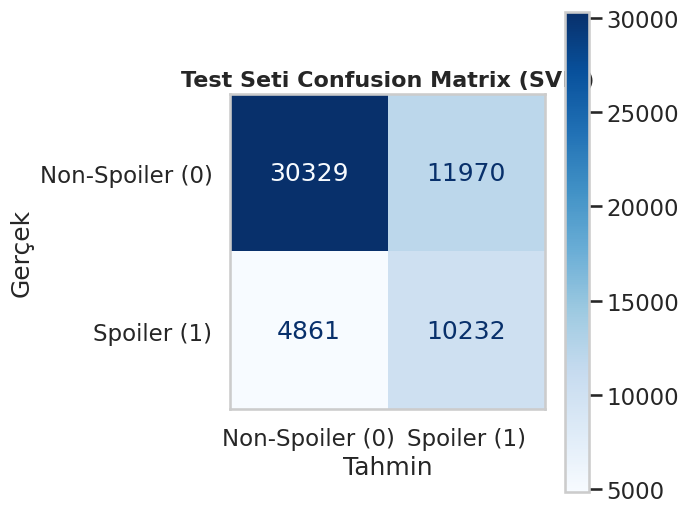

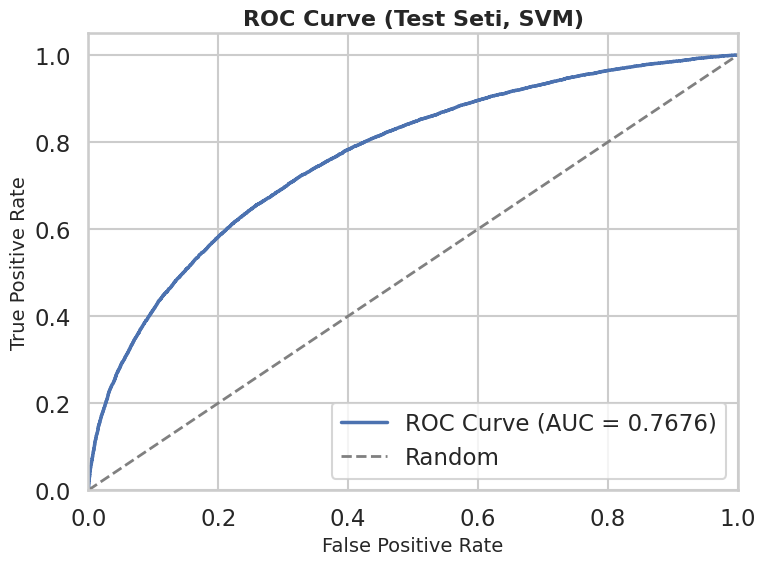

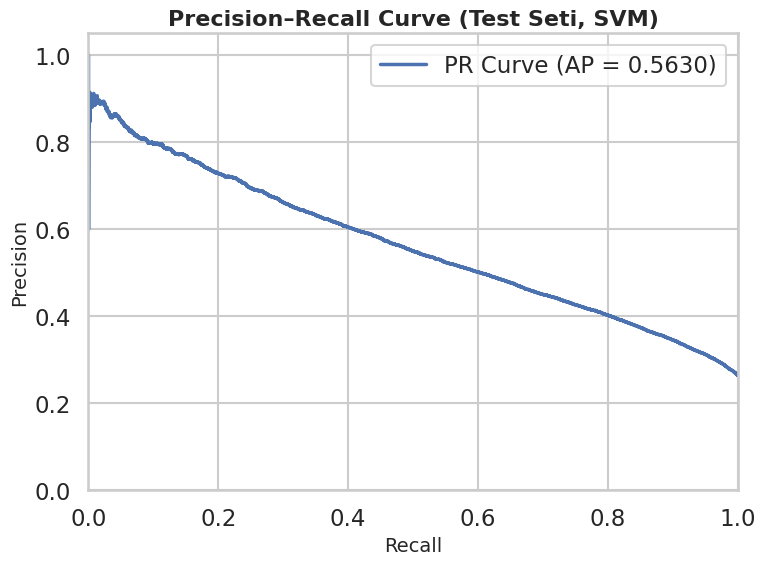

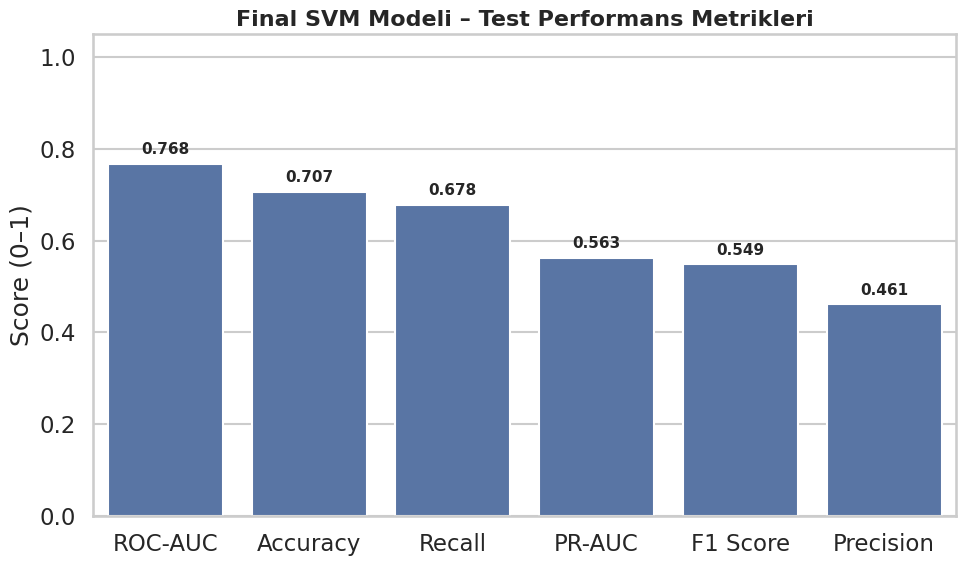

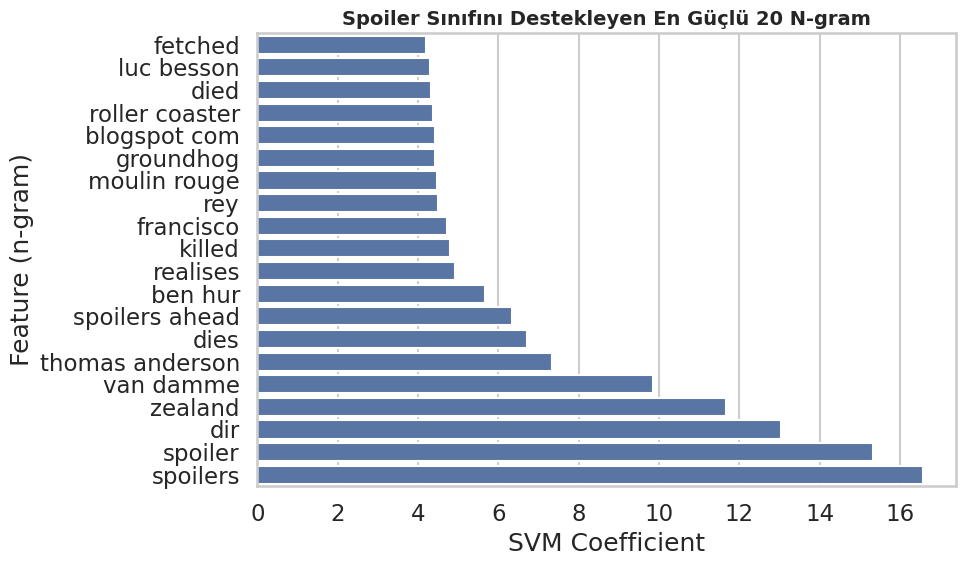

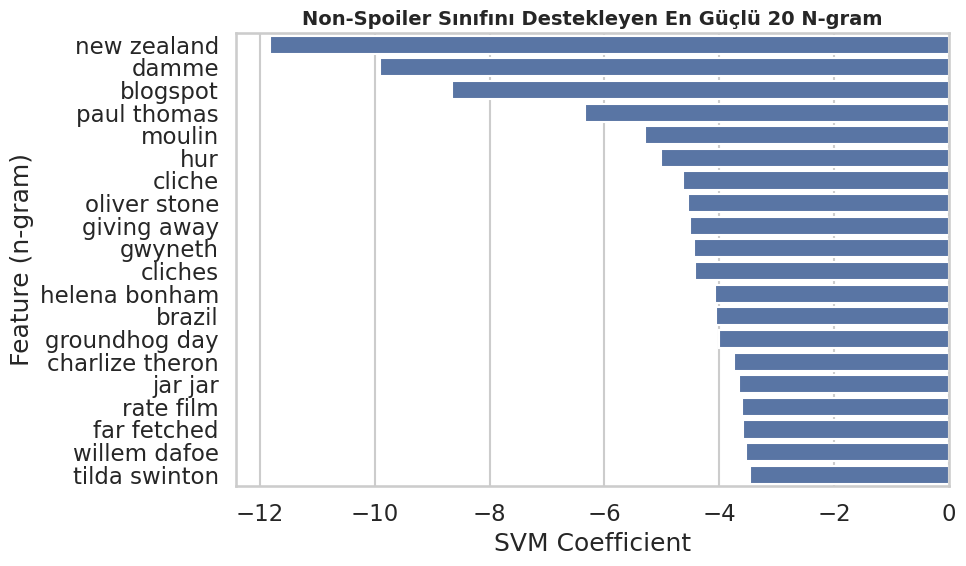

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

print("--- SVM SONUÇ GÖRSELLEŞTİRMELERİ ---")

sns.set(style="whitegrid", context="talk")

# ============================================================
# 1) Test tahminleri ve decision score (gerekirse tekrar hesapla)
# ============================================================
try:
    y_test_pred
    test_dec
except NameError:
    print("ℹ️ y_test_pred veya test_dec bulunamadı, yeniden hesaplanıyor...")
    y_test_pred = final_pipeline.predict(X_test)
    test_dec = final_pipeline.decision_function(X_test)

# ============================================================
# 2) Confusion Matrix (Test)
# ============================================================
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Non-Spoiler (0)", "Spoiler (1)"])
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Test Seti Confusion Matrix (SVM)", fontsize=16, fontweight="bold")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# 3) ROC Curve (decision_function kullanarak)
# ============================================================
fpr, tpr, _ = roc_curve(y_test, test_dec)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2.5, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve (Test Seti, SVM)", fontsize=16, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# 4) Precision-Recall Curve
# ============================================================
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_dec)
pr_auc = average_precision_score(y_test, test_dec)

plt.figure(figsize=(8, 6))
plt.plot(rec_curve, prec_curve, lw=2.5, label=f"PR Curve (AP = {pr_auc:.4f})")
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("Precision–Recall Curve (Test Seti, SVM)", fontsize=16, fontweight="bold")
plt.legend(loc="upper right")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.tight_layout()
plt.show()

# ============================================================
# 5) Metrik Özeti (Bar Chart)
# ============================================================
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, test_dec)
test_pr_auc = average_precision_score(y_test, test_dec)

metrics = {
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
}

metrics_df = (
    pd.DataFrame(list(metrics.items()), columns=["Metric", "Score"])
    .sort_values(by="Score", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Metric", y="Score", data=metrics_df)
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="center",
        xytext=(0, 10),
        textcoords="offset points",
        fontsize=11, weight="bold"
    )

plt.ylim(0, 1.05)
plt.title("Final SVM Modeli – Test Performans Metrikleri", fontsize=16, fontweight="bold")
plt.ylabel("Score (0–1)")
plt.xlabel("")
plt.tight_layout()
plt.show()

# ============================================================
# 6) En Önemli N-gram Özellikleri (LinearSVC coef_ üzerinden)
# ============================================================
try:
    svm_clf = final_pipeline.named_steps["svm"]
    tfidf_vec = final_pipeline.named_steps["tfidf"]
    feature_names = np.array(tfidf_vec.get_feature_names_out())
    coefs = svm_clf.coef_.ravel()

    # Pozitif ve negatif en güçlü 20 feature
    top_pos_idx = np.argsort(coefs)[-20:]
    top_neg_idx = np.argsort(coefs)[:20]

    top_pos_features = feature_names[top_pos_idx]
    top_pos_values = coefs[top_pos_idx]

    top_neg_features = feature_names[top_neg_idx]
    top_neg_values = coefs[top_neg_idx]

    # Pozitif (spoiler lehine) feature'lar
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_pos_values, y=top_pos_features)
    plt.title("Spoiler Sınıfını Destekleyen En Güçlü 20 N-gram", fontsize=14, fontweight="bold")
    plt.xlabel("SVM Coefficient")
    plt.ylabel("Feature (n-gram)")
    plt.tight_layout()
    plt.show()

    # Negatif (non-spoiler lehine) feature'lar
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_neg_values, y=top_neg_features)
    plt.title("Non-Spoiler Sınıfını Destekleyen En Güçlü 20 N-gram", fontsize=14, fontweight="bold")
    plt.xlabel("SVM Coefficient")
    plt.ylabel("Feature (n-gram)")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ Feature importance grafiği çizilemedi: {e}")


# **overfit görebilmek için**


📈 Overfitting learning curve (SVM, soft) hesaplanıyor...
[1] Iteration 1 - train fraction=0.10 -> 1500 örnek
[2] Iteration 2 - train fraction=0.20 -> 3000 örnek
[3] Iteration 3 - train fraction=0.35 -> 5250 örnek
[4] Iteration 4 - train fraction=0.50 -> 7500 örnek
[5] Iteration 5 - train fraction=0.65 -> 9750 örnek
[6] Iteration 6 - train fraction=0.80 -> 12000 örnek
[7] Iteration 7 - train fraction=1.00 -> 15000 örnek


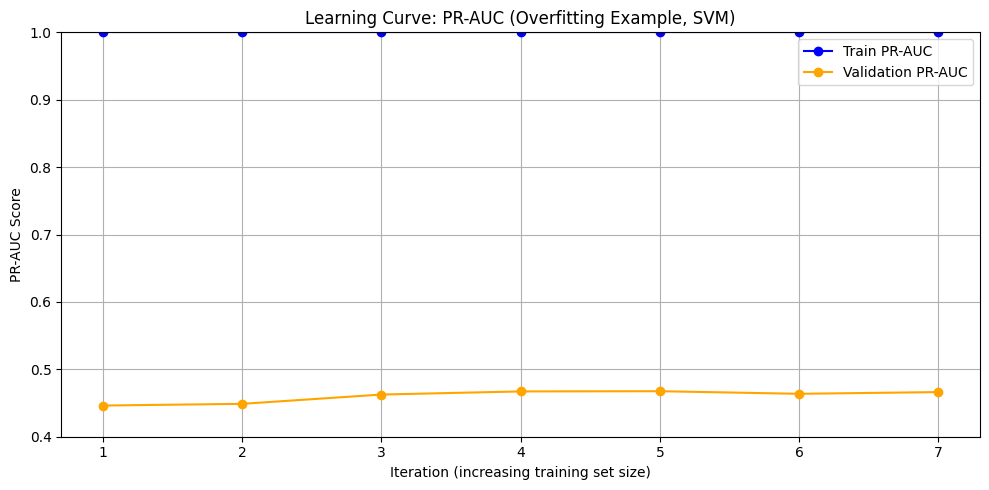

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from sklearn.base import clone

# 1) Daha "yumuşak" overfit SVM
overfit_pipeline = clone(final_pipeline)
overfit_pipeline.set_params(
    tfidf__stop_words=None,
    tfidf__max_features=100_000,   # büyük ama abartı değil
    tfidf__ngram_range=(1, 2),
    svm__C=50,                     # hâlâ yüksek, ama 1000 kadar manyak değil
    svm__class_weight=None
)

# Overfit için küçük bir base train set (örn. 15k)
X_train_base, _, y_train_base, _ = train_test_split(
    X_train,
    y_train,
    train_size=15_000,
    stratify=y_train,
    random_state=42
)

fractions = [0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0]

iters = []
train_pr_auc = []
val_pr_auc = []

print("\n📈 Overfitting learning curve (SVM, soft) hesaplanıyor...")

for i, frac in enumerate(fractions, start=1):
    if frac == 1.0:
        X_sub = X_train_base
        y_sub = y_train_base
    else:
        X_sub, _, y_sub, _ = train_test_split(
            X_train_base,
            y_train_base,
            train_size=frac,
            stratify=y_train_base,
            random_state=42
        )

    print(f"[{i}] Iteration {i} - train fraction={frac:.2f} -> {len(X_sub)} örnek")

    model = clone(overfit_pipeline)
    model.fit(X_sub, y_sub)

    # TRAIN PR-AUC
    train_dec = model.decision_function(X_sub)
    pr_train = average_precision_score(y_sub, train_dec)

    # VALIDATION PR-AUC
    val_dec = model.decision_function(X_val)
    pr_val = average_precision_score(y_val, val_dec)

    iters.append(i)
    train_pr_auc.append(pr_train)
    val_pr_auc.append(pr_val)

plt.figure(figsize=(10, 5))
plt.plot(iters, train_pr_auc, marker="o", label="Train PR-AUC", color="blue")
plt.plot(iters, val_pr_auc,   marker="o", label="Validation PR-AUC", color="orange")
plt.title("Learning Curve: PR-AUC (Overfitting Example, SVM)")
plt.xlabel("Iteration (increasing training set size)")
plt.ylabel("PR-AUC Score")
plt.ylim(0.4, 1.0)   # alt sınırı biraz yukarı al, şekil daha net olsun
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# **Regularizasyon'u tek hücrede görmek için**

In [ ]:
from sklearn.base import clone
from sklearn.metrics import f1_score, precision_score, recall_score

Cs = [1, 10, 100, 1000, 10000, 100000]

print("\n🔍 C değerini büyüterek regularization'ı zayıflatma deneyi (SVM):")

for C in Cs:
    model = clone(final_pipeline)
    model.set_params(svm__C=C)

    print(f"\nC = {C}")
    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    f1_tr = f1_score(y_train, y_tr)
    f1_val = f1_score(y_val, y_val_pred)
    rec_tr = recall_score(y_train, y_tr)
    rec_val = recall_score(y_val, y_val_pred)

    print(f"  TRAIN F1: {f1_tr:.4f},  VAL F1: {f1_val:.4f}")
    print(f"  TRAIN Recall: {rec_tr:.4f}, VAL Recall: {rec_val:.4f}")
    print(f"  GAP F1: {f1_tr - f1_val:.4f}")



🔍 C değerini büyüterek regularization'ı zayıflatma deneyi (SVM):

C = 1


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  TRAIN F1: 0.5784,  VAL F1: 0.5527
  TRAIN Recall: 0.6862, VAL Recall: 0.6572
  GAP F1: 0.0257

C = 10


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  TRAIN F1: 0.5792,  VAL F1: 0.5509
  TRAIN Recall: 0.6895, VAL Recall: 0.6567
  GAP F1: 0.0283

C = 100


...

  TRAIN F1: 0.5494,  VAL F1: 0.5211
  TRAIN Recall: 0.6625, VAL Recall: 0.6302
  GAP F1: 0.0283

C = 10000


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  TRAIN F1: 0.4586,  VAL F1: 0.4449
  TRAIN Recall: 0.4796, VAL Recall: 0.4661
  GAP F1: 0.0137

C = 100000


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  TRAIN F1: 0.4586,  VAL F1: 0.4449
  TRAIN Recall: 0.4796, VAL Recall: 0.4661
  GAP F1: 0.0137
